# v_r_v2 Evaluation

Dieses Notebook bewertet `v_r_v2` mit derselben Mehrklassen-Labelauswahl wie die Random-Forest-Baseline und zeigt die Kennzahlen inklusive grafischer Confusion Matrix.

In [1]:
import sys
from pathlib import Path

import pandas as pd
from IPython.display import display

def find_repo_root(start: Path) -> Path:
    for candidate in [start.resolve(), *start.resolve().parents]:
        if (candidate / "src" / "vr_v2_model").exists():
            return candidate
    raise FileNotFoundError("Repo root mit src/vr_v2_model wurde nicht gefunden.")

repo_root = find_repo_root(Path.cwd())
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from src.random_forest_baseline.config import BaselineConfig
from src.random_forest_baseline.data import prepare_dataset
from src.random_forest_baseline.modeling import evaluate_grouped_dataset, save_confusion_matrix_plot

config = BaselineConfig.from_json(repo_root / "models/v_r_v2/config.json")
config

BaselineConfig(data_dir='Daten/Daten_Labeled', output_dir='models/v_r_v2/output', model_output_path='models/v_r_v2/output/v_r_v2.pkl', window_before_s=0.5, window_after_s=0.5, min_window_rows=25, labels=['Vorhand', 'Rueckhand', 'Schlaeger drehen', 'Aufschlag von unten', 'Kein Schlag / Other'], excluded_labels=['Unsicher'], min_samples_per_label=10, min_sessions_per_label=2, random_state=42, n_estimators=400, max_depth=None, min_samples_leaf=2, class_weight='balanced_subsample')

In [2]:
dataset = prepare_dataset(config)
display(dataset.label_summary)
display(dataset.metadata.head())
print(f"Events: {len(dataset.labels)} | Sessions: {dataset.groups.nunique()} | Features: {dataset.features.shape[1]}")

,label_name,total_events,session_count
0,Vorhand,170,3
1,Rueckhand,95,3
2,Schlaeger drehen,53,2
3,Aufschlag von unten,38,2
4,Kein Schlag / Other,21,3


,session_name,event_index,event_time_s,window_start_s,window_end_s,window_rows,label_name
0,fritz_1_Labeled.csv,11534,116.219257,115.719257,116.719257,99,Rueckhand
1,fritz_1_Labeled.csv,11832,119.222006,118.722006,119.722006,99,Rueckhand
2,fritz_1_Labeled.csv,12133,122.254987,121.754987,122.754987,99,Vorhand
3,fritz_1_Labeled.csv,12499,125.942926,125.442926,126.442926,99,Vorhand
4,fritz_1_Labeled.csv,12805,129.026281,128.526281,129.526281,99,Vorhand


Events: 377 | Sessions: 3 | Features: 164


In [3]:
result = evaluate_grouped_dataset(dataset, config)
display(pd.DataFrame([result.overall_metrics]))
display(result.classification_report)
display(result.fold_metrics)

,event_count,feature_count,session_count,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1
0,377.0,164.0,3.0,0.885942,0.741074,0.737571,0.741074,0.737386,0.886712


,label,precision,recall,f1-score,support
0,Vorhand,0.976471,0.976471,0.976471,170.000000
1,Rueckhand,0.977011,0.894737,0.934066,95.000000
2,Schlaeger drehen,0.734375,0.886792,0.803419,53.000000
3,Aufschlag von unten,1.000000,0.947368,0.972973,38.000000
4,Kein Schlag / Other,0.000000,0.000000,0.000000,21.000000
5,accuracy,0.885942,0.885942,0.885942,0.885942
6,macro avg,0.737571,0.741074,0.737386,377.000000
7,weighted avg,0.890552,0.885942,0.886712,377.000000


,fold,test_session,train_events,test_events,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1
0,1,fritz_1_Labeled.csv,230,147,0.850340,0.681889,0.785837,0.681889,0.728722,0.907594
1,2,fritz_2_Labeled.csv,292,85,0.929412,0.666667,0.500000,0.500000,0.500000,0.929412
2,3,fritz_3_Labeled.csv,232,145,0.896552,0.790476,0.724399,0.790476,0.753162,0.853789


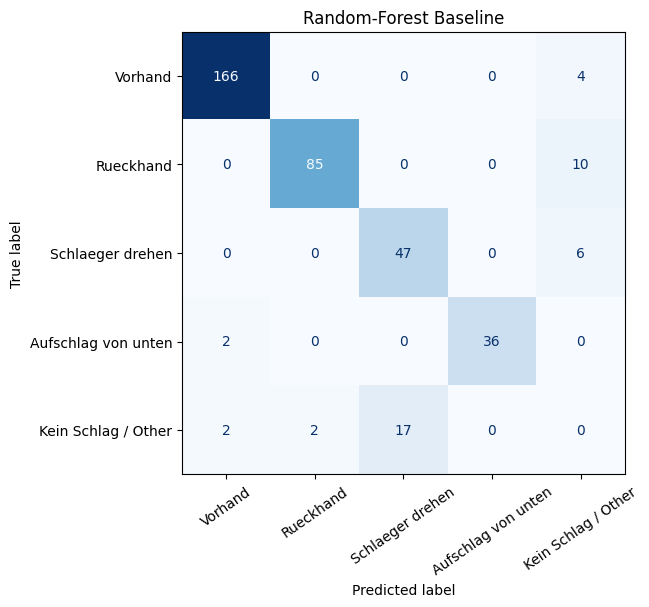

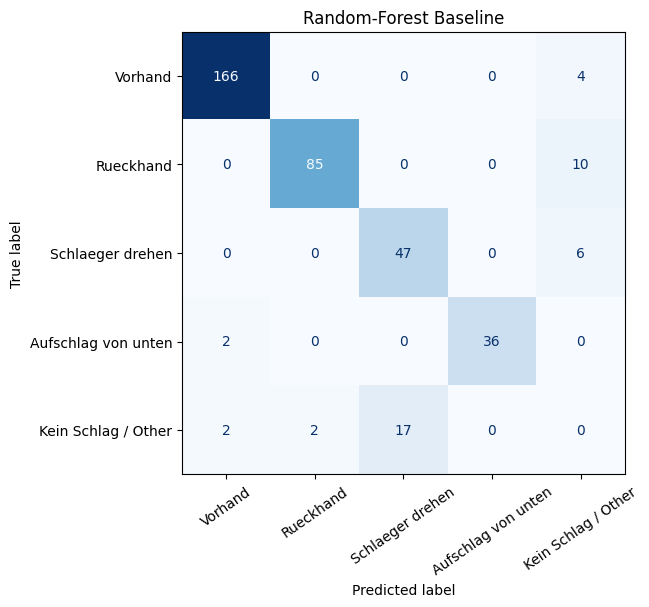

In [4]:
figure = save_confusion_matrix_plot(result.confusion_matrix)
figure

## Anpassung

Wenn ihr Zeitfenster, Labels oder Hyperparameter aendern wollt, passt `models/v_r_v2/config.json` an und fuehrt das Notebook erneut aus.